In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

Data loading and understanding

In [142]:
df = pd.read_csv(r'D:\churn\src\notebook\data\customer_churn.csv')

In [143]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [144]:
df.shape

(7043, 21)

In [145]:
pd.set_option('display.max_columns',None)

In [146]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [148]:
df = df.drop('customerID',axis = 1)

In [149]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [150]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [151]:
print(df['SeniorCitizen'].unique())

[0 1]


In [152]:
print(df['Partner'].unique())

['Yes' 'No']


In [153]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in df.columns:
  if col not in numerical_cols:
    print(f'{col} : {df[col].unique()}')

gender : ['Female' 'Male']
SeniorCitizen : [0 1]
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


In [154]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [155]:
df[df['TotalCharges'] == ' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [156]:
len(df[df['TotalCharges'] == ' '])

11

In [157]:
df['TotalCharges'] = df['TotalCharges'].replace(' ','0.0').astype(float)

In [158]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [159]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


EDA

In [160]:
df.shape

(7043, 20)

In [161]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [162]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [163]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


Plots

histogram

In [164]:
def plot_histogram(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  # calculate the mean and median values for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

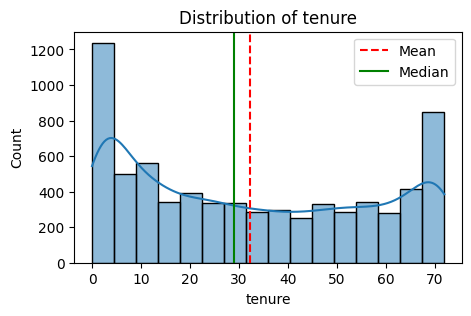

In [165]:
plot_histogram(df,'tenure')

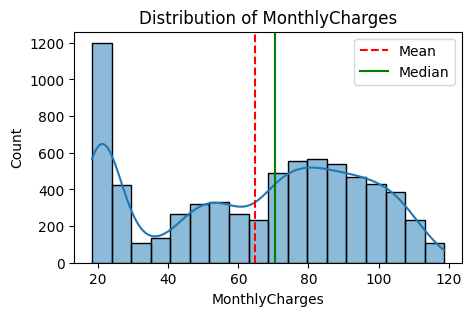

In [166]:
plot_histogram(df,'MonthlyCharges')

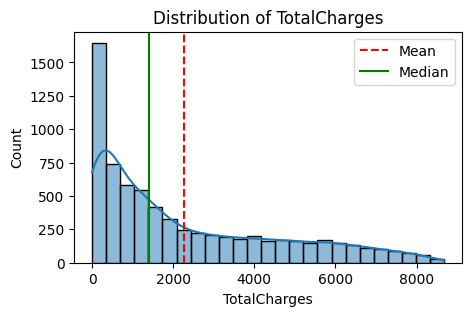

In [167]:
plot_histogram(df,"TotalCharges")

Box plot

In [168]:
def boxplot(df, column_name):
  plt.figure(figsize = (5,3))
  sns.boxplot(df[column_name])
  plt.title(f"Boxplot of {column_name}")
  plt.ylabel('column_name')
  plt.show()

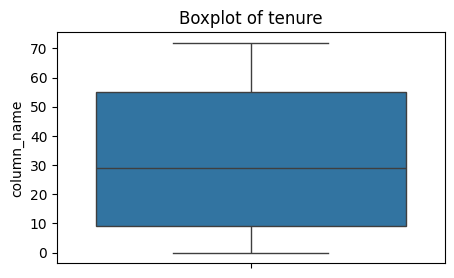

In [169]:
boxplot(df,'tenure')

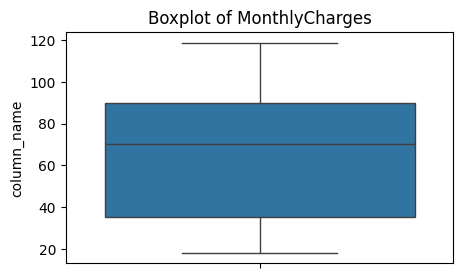

In [170]:
boxplot(df,'MonthlyCharges')

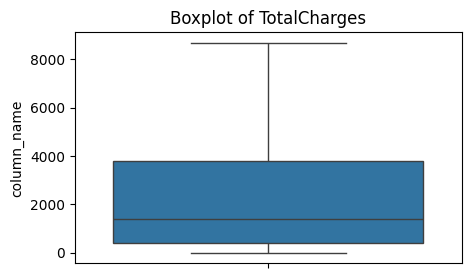

In [171]:
boxplot(df,'TotalCharges')

Correlation heatmap

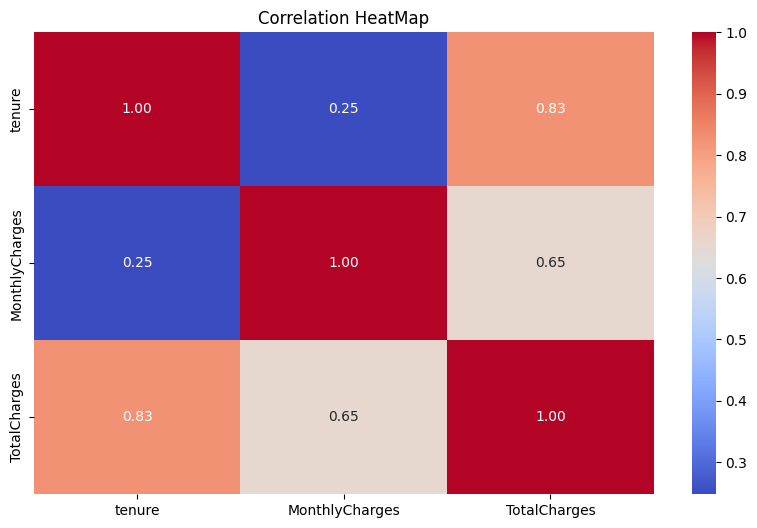

In [174]:
plt.figure(figsize = (10,6))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation HeatMap')
plt.show()

In [176]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


Count plot

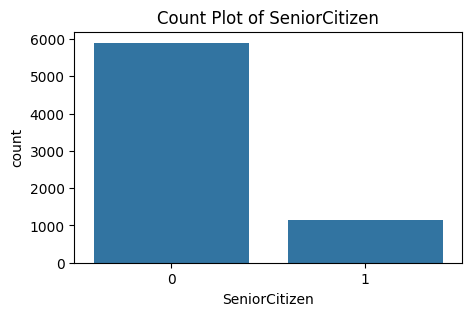

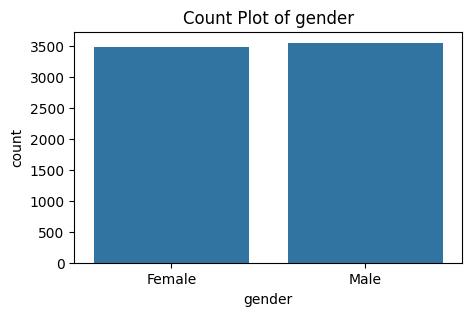

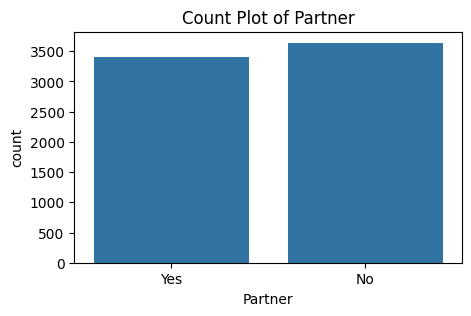

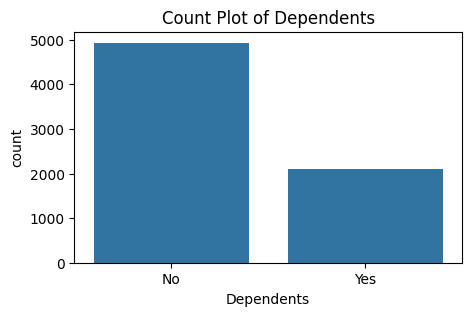

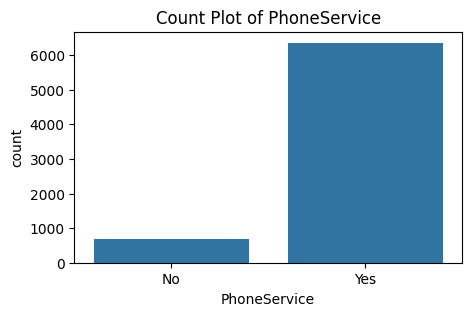

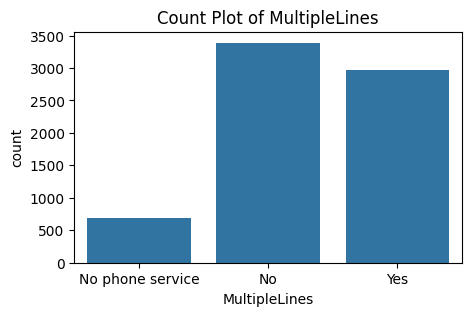

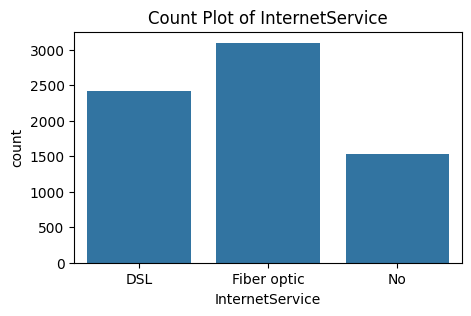

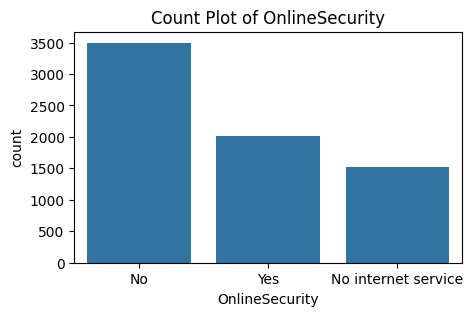

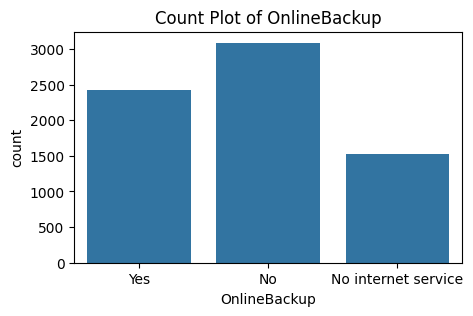

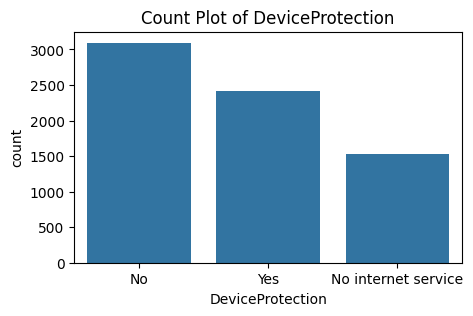

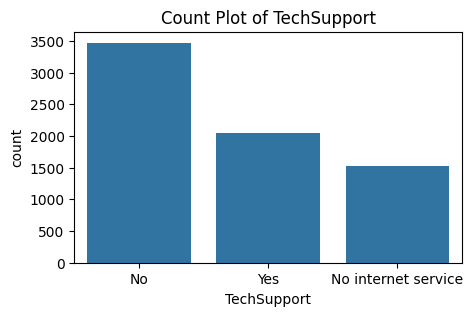

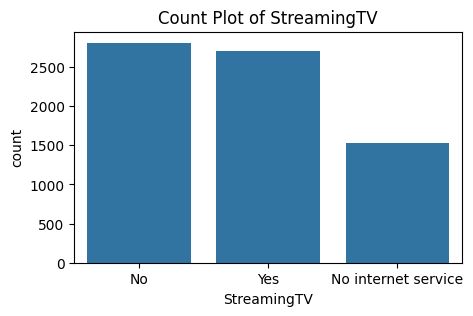

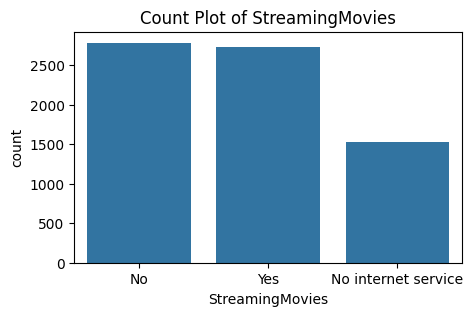

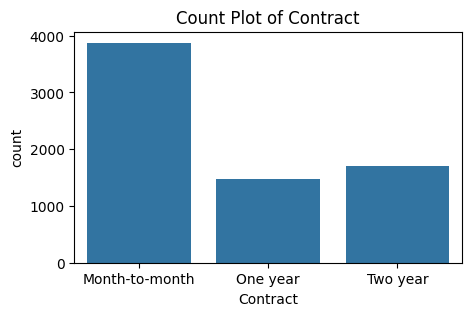

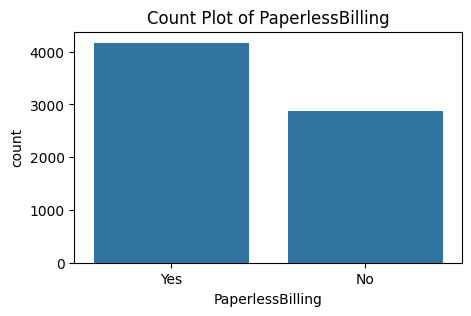

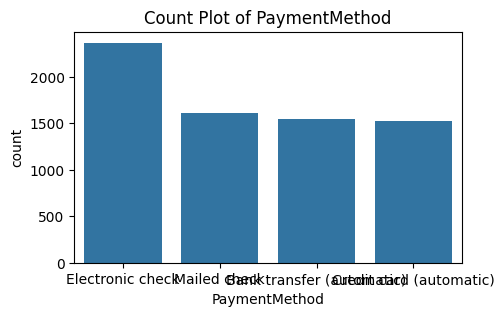

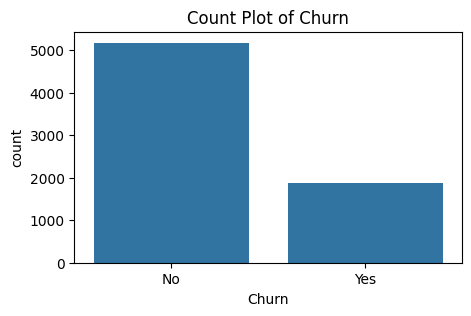

In [178]:
object_cols = df.select_dtypes(include="object").columns.to_list()

object_cols = ["SeniorCitizen"] + object_cols

for col in object_cols:
  plt.figure(figsize=(5, 3))
  sns.countplot(x=df[col])
  plt.title(f"Count Plot of {col}")
  plt.show()

Data preprocessing

In [179]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [180]:
df['Churn'] = df['Churn'].replace({"Yes": 1, "No" : 0})

In [181]:
df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0


In [182]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [183]:
object_cols = df.select_dtypes(include = 'object').columns

In [184]:
object_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [186]:
encoders = {}

for col in object_cols:
  label_encoder = LabelEncoder()
  df[col] = label_encoder.fit_transform(df[col])
  encoders[col] = label_encoder


In [187]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [188]:
df['AverageCharges'] = df['TotalCharges'] / df['tenure'].replace(0, np.nan)
df['AverageCharges'] = df['AverageCharges'].fillna(df['AverageCharges'].mean())

In [189]:
df.drop(['TotalCharges', 'tenure'], axis=1, inplace=True)

In [190]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,AverageCharges
0,0,0,1,0,0,1,0,0,2,0,0,0,0,0,1,2,29.85,0,29.850000
1,1,0,0,0,1,0,0,2,0,2,0,0,0,1,0,3,56.95,0,55.573529
2,1,0,0,0,1,0,0,2,2,0,0,0,0,0,1,3,53.85,1,54.075000


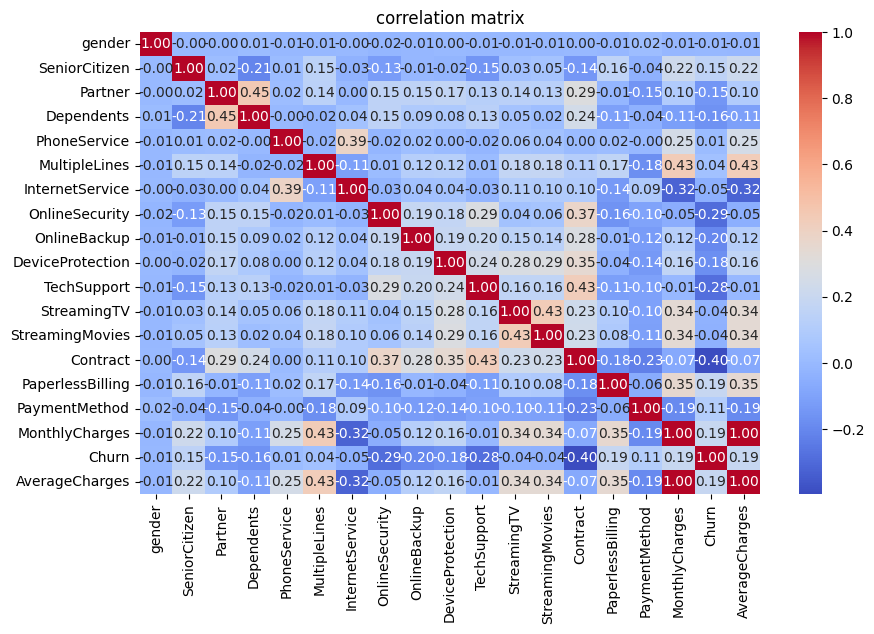

In [191]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("correlation matrix")
plt.show()


Training and test data split

In [ ]:
X = df.drop('Churn', axis = 1)
Y = df['Churn']

In [192]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.25,random_state = 2529, stratify = Y)

In [193]:
print(Y_train.shape)

(5282,)


In [194]:
print(Y_train.value_counts())

Churn
0    3880
1    1402
Name: count, dtype: int64


SMOTE

In [309]:
smote = SMOTE(random_state = 42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train,Y_train)

smote = SMOTE(random_state=42, sampling_strategy='minority')
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)


ValueError: Found input variables with inconsistent numbers of samples: [7761, 5282]

In [196]:
print(Y_train_resampled.shape)

(7760,)


In [197]:
print(Y_train_resampled.value_counts())

Churn
1    3880
0    3880
Name: count, dtype: int64


MOdel Training

In [198]:
models = {
    'Decision Tree' : DecisionTreeClassifier(),
    'Random Forest' : RandomForestClassifier(),
    'XGBoost' : XGBClassifier(),
    'Logisticregression': LogisticRegression()
}

In [199]:
cv_scores = {}

for model_name, model in models.items():
  print(f"Training {model_name} with default parameters")
  model.fit(X_train_resampled,Y_train_resampled)
  scores = cross_val_score(model,X_train_resampled,Y_train_resampled,cv = 5)
  cv_scores[model_name] = scores

  print(f"{model_name} cross validation accuracy : { np.mean(scores): .2f}")
  print('---'*10)

Training Decision Tree with default parameters
Decision Tree cross validation accuracy :  0.78
------------------------------
Training Random Forest with default parameters
Random Forest cross validation accuracy :  0.83
------------------------------
Training XGBoost with default parameters
XGBoost cross validation accuracy :  0.82
------------------------------
Training Logisticregression with default parameters
Logisticregression cross validation accuracy :  0.78
------------------------------


In [200]:
cv_scores

{'Decision Tree': array([0.71842784, 0.72229381, 0.82216495, 0.80541237, 0.80927835]),
 'Random Forest': array([0.75193299, 0.7693299 , 0.87628866, 0.87242268, 0.87177835]),
 'XGBoost': array([0.73518041, 0.75966495, 0.87435567, 0.85953608, 0.87564433]),
 'Logisticregression': array([0.73195876, 0.73324742, 0.82152062, 0.80412371, 0.80863402])}

rfc is the best model for this data

In [201]:
rfc = RandomForestClassifier(
max_depth = 10,
min_samples_split = 2,
)
rfc.fit(X_train_resampled, Y_train_resampled)


RandomForestClassifier(max_depth=10)

In [202]:
lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train_resampled,Y_train_resampled)

LogisticRegression(max_iter=1000)

In [203]:
# Assuming you have a trained model `rfc`
y_pred_train = rfc.predict(X_train_resampled)  # predicted labels for training data

print("accuracy_score:", accuracy_score(Y_train_resampled, y_pred_train))


accuracy_score: 0.8877577319587628


In [204]:
y_pred_train = lr.predict(X_train_resampled)  # predicted labels for training data

print("accuracy_score:", accuracy_score(Y_train_resampled, y_pred_train))


accuracy_score: 0.7880154639175257


In [205]:
Y_test_pred = rfc.predict(X_test)
print("Accuracy score:\n" , accuracy_score(Y_test,Y_test_pred))
print("confusion matrix:\n", confusion_matrix(Y_test,Y_test_pred))
print("classification report:\n", classification_report(Y_test,Y_test_pred))

Accuracy score:
 0.7632027257240205
confusion matrix:
 [[1008  286]
 [ 131  336]]
classification report:
               precision    recall  f1-score   support

           0       0.88      0.78      0.83      1294
           1       0.54      0.72      0.62       467

    accuracy                           0.76      1761
   macro avg       0.71      0.75      0.72      1761
weighted avg       0.79      0.76      0.77      1761



In [206]:
Y_test_pred = lr.predict(X_test)
print("Accuracy score:\n" , accuracy_score(Y_test,Y_test_pred))
print("confusion matrix:\n", confusion_matrix(Y_test,Y_test_pred))
print("classification report:\n", classification_report(Y_test,Y_test_pred))

Accuracy score:
 0.740488358886996
confusion matrix:
 [[946 348]
 [109 358]]
classification report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.81      1294
           1       0.51      0.77      0.61       467

    accuracy                           0.74      1761
   macro avg       0.70      0.75      0.71      1761
weighted avg       0.79      0.74      0.75      1761



In [207]:
ensemble = VotingClassifier(estimators=[
    ('rfc',RandomForestClassifier(max_depth = 10)),
    ('xgb',XGBClassifier()),
    ('lr', LogisticRegression())
    
],voting = 'soft')

In [208]:
ensemble.fit(X_train_resampled,Y_train_resampled)

VotingClassifier(estimators=[('rfc', RandomForestClassifier(max_depth=10)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lr', LogisticRegression())],
                 voting='soft')

In [209]:
y_pred_train = ensemble.predict(X_train_resampled)

print("accuracy score :" ,accuracy_score(Y_train_resampled,y_pred_train))

accuracy score : 0.8847938144329897


In [210]:
Y_test_pred = ensemble.predict(X_test)
print("Accuracy score:\n" , accuracy_score(Y_test,Y_test_pred))
print("confusion matrix:\n", confusion_matrix(Y_test,Y_test_pred))
print("classification report:\n", classification_report(Y_test,Y_test_pred))

Accuracy score:
 0.7614991482112436
confusion matrix:
 [[1009  285]
 [ 135  332]]
classification report:
               precision    recall  f1-score   support

           0       0.88      0.78      0.83      1294
           1       0.54      0.71      0.61       467

    accuracy                           0.76      1761
   macro avg       0.71      0.75      0.72      1761
weighted avg       0.79      0.76      0.77      1761



In [211]:
from sklearn.metrics import roc_auc_score

y_scores = ensemble.predict_proba(X_test)[:, 1]  # probability of positive class (churn)
auc = roc_auc_score(Y_test, y_scores)
print("ROC-AUC:", auc)


ROC-AUC: 0.8185663364763743


In [255]:
y = df['Churn']
X = df.drop('Churn',axis=1)

In [256]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [257]:
from imblearn.over_sampling import RandomOverSampler

In [275]:
from imblearn.over_sampling import SMOTE

In [276]:
smote = SMOTE()

In [293]:
A,B = smote.fit_resample(A,B)

In [297]:
A_train,A_test,B_train,B_test=train_test_split(A,B,random_state=2529)

In [298]:
rfc = RandomForestClassifier(max_depth = 10)

In [299]:
rfc.fit(A_train,B_train)

RandomForestClassifier(max_depth=10)

In [300]:
b_pred = rfc.predict(A_test)

In [301]:
a_pred = rfc.predict(A_train)

In [302]:
print(accuracy_score(a_pred,B_train))

0.8895760855559851


In [303]:
print(accuracy_score(b_pred,B_test))

0.8175492848859683


In [305]:
Y_test_pred = rfc.predict(A_test)
print("Accuracy score:\n" , accuracy_score(B_test,Y_test_pred))
print("confusion matrix:\n", confusion_matrix(B_test,Y_test_pred))
print("classification report:\n", classification_report(B_test,Y_test_pred))

Accuracy score:
 0.8175492848859683
confusion matrix:
 [[ 924  366]
 [ 106 1191]]
classification report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1290
           1       0.76      0.92      0.83      1297

    accuracy                           0.82      2587
   macro avg       0.83      0.82      0.82      2587
weighted avg       0.83      0.82      0.82      2587



In [306]:
from sklearn.metrics import roc_auc_score

y_scores = rfc.predict_proba(X_test)[:, 1]  # probability of positive class (churn)
auc = roc_auc_score(y_test, y_scores)
print("ROC-AUC:", auc)


ROC-AUC: 0.8808239646650291


In [258]:
ros = RandomOverSampler()


In [259]:
X,y = ros.fit_resample(X,y)

In [260]:

y.value_counts()

Churn
0    5174
1    5174
Name: count, dtype: int64

In [261]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,AverageCharges
0,0,0,1,0,0,1,0,0,2,0,0,0,0,0,1,2,29.85,0,29.850000
1,1,0,0,0,1,0,0,2,0,2,0,0,0,1,0,3,56.95,0,55.573529


In [285]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=2529)

In [286]:
rfc = RandomForestClassifier(max_depth = 10)

In [287]:
rfc.fit(X_train,y_train)

RandomForestClassifier(max_depth=10)

In [288]:
y_pred = rfc.predict(X_test)

In [289]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.72      0.79      1290
           1       0.76      0.91      0.83      1297

    accuracy                           0.81      2587
   macro avg       0.83      0.81      0.81      2587
weighted avg       0.83      0.81      0.81      2587



In [290]:
print(accuracy_score(y_test,y_pred))

0.8132972555083108


In [291]:
x_pred = rfc.predict(X_train)

In [292]:
print(accuracy_score(x_pred,y_train))

0.8904780311815488


In [274]:
from sklearn.metrics import roc_auc_score

y_scores = rfc.predict_proba(X_test)[:, 1]  # probability of positive class (churn)
auc = roc_auc_score(y_test, y_scores)
print("ROC-AUC:", auc)


ROC-AUC: 0.880063414080197
